In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as sm
import scipy.stats as stats
import seaborn as sns

In [3]:
import os
# Importa a biblioteca 'os', usada para interagir com o sistema de arquivos
# (listar pastas, verificar caminhos, etc.)

import requests
# Importa a biblioteca 'requests', usada para fazer requisições HTTP
# (baixar dados da internet, APIs, etc.) — aqui você não está usando ainda

from google.colab import drive
# Importa o módulo do Colab que permite acessar o Google Drive

drive.mount('/content/drive')
# Monta (conecta) o Google Drive no ambiente do Colab
# Depois disso, seus arquivos ficam disponíveis em /content/drive/MyDrive

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Curso completo inteligencia artificial/3.Algoritmos de Machine Learning/mt_cars.csv')
# Lê o arquivo CSV do seu Google Drive
# e carrega os dados em um DataFrame chamado 'df'

df.head()
# Mostra as primeiras 5 linhas do DataFrame
# Serve para visualizar rapidamente se os dados foram carregados corretamente

Mounted at /content/drive


,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [4]:
# Mostra as 5 primeiras linhas do DataFrame base
import pandas as pd

base = df
base.head()

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


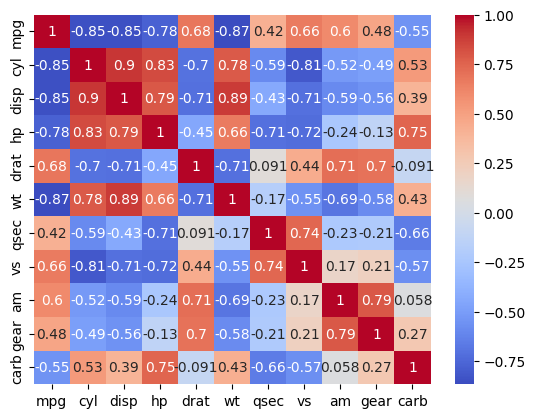

In [5]:
#calcula a correlação só das colunas numéricas (evita erro 💥)
corr = base.corr(numeric_only=True)
# cria o mapa de calor das correlações
sns.heatmap(corr, cmap="coolwarm", annot=True)
#exibe o gráfico
plt.show()

#interpretação
#mpg vs wt → -0.87 → 🔴 correlação forte negativa
#mpg vs cyl → -0.85 → 🔴 forte negativa
#mpg vs disp → -0.85 → 🔴 forte negativa
#mpg vs hp → -0.78 → 🔴 forte negativa
#mpg vs vs → 0.66 → 🟡 correlação moderada positiva

In [8]:
corr = base.corr(numeric_only=True)

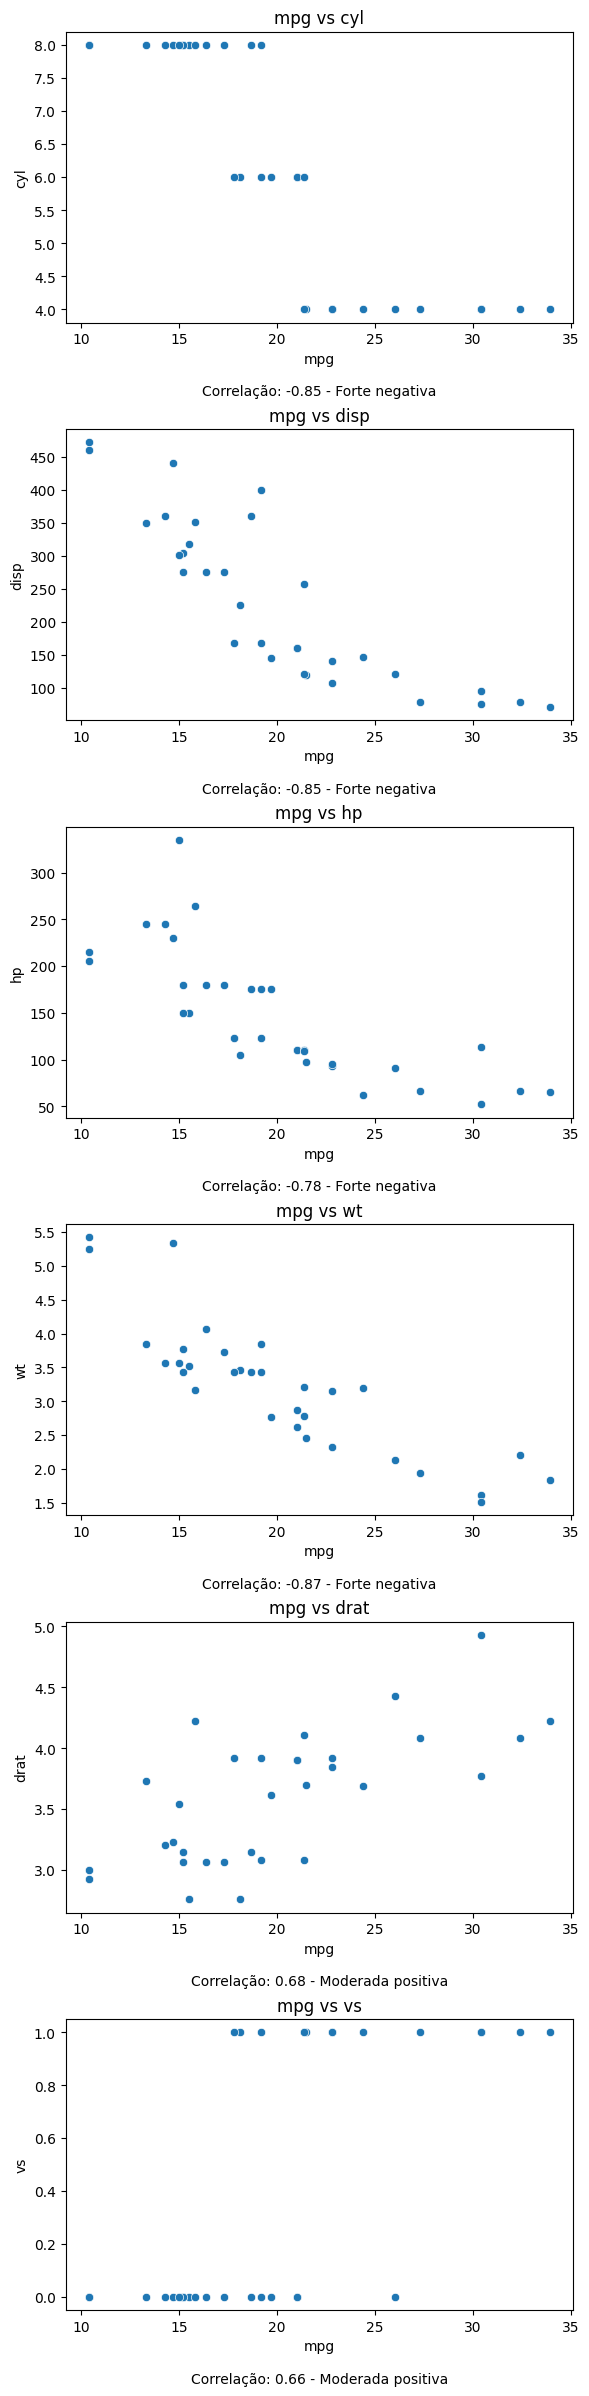

In [11]:
# Importa as bibliotecas necessárias
import seaborn as sns              # Biblioteca para visualização de dados (baseada no matplotlib)
import matplotlib.pyplot as plt    # Biblioteca para criação de gráficos

# Define os pares de colunas que serão analisados
# Cada tupla representa (eixo X, eixo Y)
column_pairs = [
    ('mpg','cyl'),
    ('mpg','disp'),
    ('mpg','hp'),
    ('mpg','wt'),
    ('mpg','drat'),
    ('mpg','vs')
]

# Calcula quantos gráficos serão gerados
n_plots = len(column_pairs)

# Cria a área de plotagem com vários subplots (um abaixo do outro)
# figsize define o tamanho da figura (largura, altura)
fig, axes = plt.subplots(nrows=n_plots, ncols=1, figsize=(6, 4 * n_plots))

# Loop para gerar cada gráfico
for i, pair in enumerate(column_pairs):

    # Separa as colunas X e Y
    x_col, y_col = pair

    # Cria o gráfico de dispersão (scatterplot)
    # Mostra a relação entre duas variáveis
    sns.scatterplot(x=x_col, y=y_col, data=base, ax=axes[i])

    # Calcula a correlação entre as duas variáveis
    # .corr() gera a matriz de correlação
    # .iloc[0,1] pega o valor da correlação entre X e Y
    corr = base[[x_col, y_col]].corr().iloc[0,1]

    # Classifica a força da correlação
    if corr > 0.7:
        interpretacao = "Forte positiva"
    elif corr < -0.7:
        interpretacao = "Forte negativa"
    elif corr > 0.3:
        interpretacao = "Moderada positiva"
    elif corr < -0.3:
        interpretacao = "Moderada negativa"
    else:
        interpretacao = "Fraca"

    # Define o título do gráfico
    axes[i].set_title(f'{x_col} vs {y_col}')

    # Adiciona um texto abaixo do gráfico com o valor da correlação
    axes[i].text(
        0.5, -0.25,   # posição do texto (centralizado abaixo do gráfico)
        f'Correlação: {corr:.2f} - {interpretacao}',  # texto exibido
        transform=axes[i].transAxes,  # usa coordenadas relativas ao eixo
        ha='center',   # centraliza horizontalmente
        fontsize=10    # tamanho da fonte
    )

# Ajusta automaticamente os espaçamentos entre os gráficos
plt.tight_layout()

# Exibe todos os gráficos
plt.show()

In [14]:
residuos = modelo.resid
plt.hist(residuos, bins=20)
plt.xlabel("Residuos")
plt.ylabel("Frequencia")
plt.title("Histograma de Residuos")
plt.show()

NameError: name 'modelo' is not defined

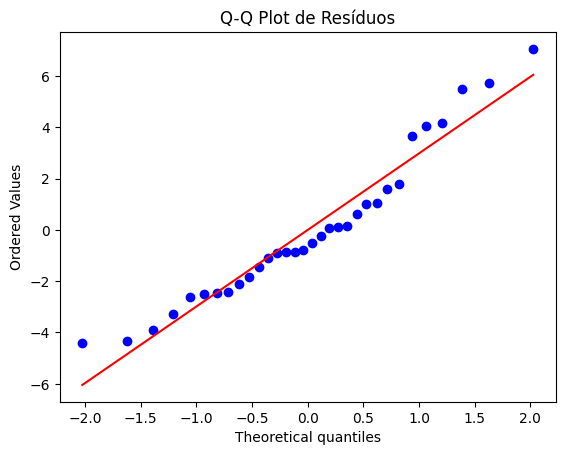

In [17]:
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt

# Define as variáveis dependente (y) e independentes (X)
y = base['mpg']
X = base[['disp', 'cyl']]
# Adiciona uma constante ao modelo para o intercepto
X = sm.add_constant(X)

# Ajusta o modelo
modelo = sm.OLS(y, X).fit()

# Calcula os resíduos
residuos = modelo.resid

# Q-Q Plot
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("Q-Q Plot de Resíduos")
plt.show()

In [19]:
import statsmodels.formula.api as smf
modelo = smf.ols(formula="mpg ~ disp + cyl",data=base)
modelo = modelo.fit()
modelo.summary()
#

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     45.81
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           1.06e-09
Time:                        19:47:32   Log-Likelihood:                -79.573
No. Observations:                  32   AIC:                             165.1
Df Residuals:                      29   BIC:                             169.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     34.6610      2.547     13.609      0.000      29.452      39.870
disp          -0.0206      0.010     -2.007      0.054      -0.042       0.000
cyl           -1.5873      0.712     -2.230      0.034      -3.043      -0.131
==============================================================================
Omnibus:                        3.200   Durbin-Watson:                   1.596
Prob(Omnibus):                  0.202   Jarque-Bera (JB):                2.660
Skew:                           0.701   Prob(JB):                        0.264
Kurtosis:                       2.822   Cond. No.                     1.27e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.27e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

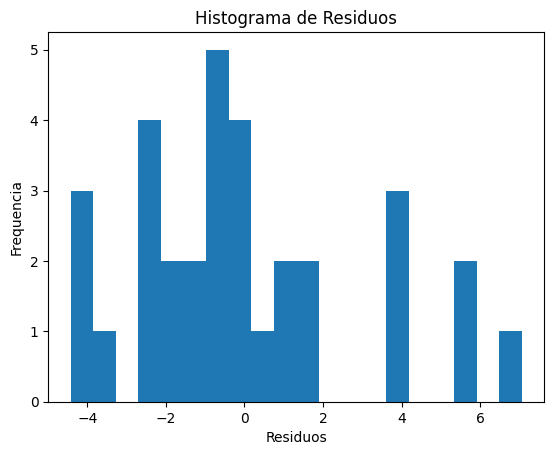

In [20]:
residous = modelo.resid
plt.hist(residuos, bins=20)
plt.xlabel("Residuos")
plt.ylabel("Frequencia")
plt.title("Histograma de Residuos")
plt.show()

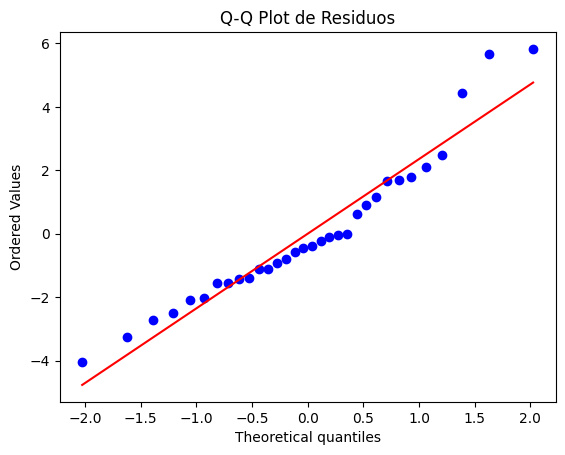

In [ ]:
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("Q-Q Plot de Residuos")
plt.show()

In [22]:
import statsmodels.formula.api as smf
from scipy import stats

modelo = smf.ols(formula="mpg ~ disp + cyl", data=base)
modelo = modelo.fit()

# 🔥 ESSA LINHA É A CHAVE
residuos = modelo.resid

# Shapiro
stat, pval = stats.shapiro(residuos)

print(f'Shapiro-Wilk: {stat:.3f}, p-value {pval:.3f}')

# Como o p-valor (0.085) é maior que 0.05,
# não rejeitamos a hipótese nula.
# Portanto, os resíduos podem ser considerados aproximadamente normais.

Shapiro-Wilk: 0.942, p-value 0.085
